In [52]:
import pandas as pd

In [53]:
df = pd.read_csv("data/cars_fuel_efficiency.csv")
print("Dataset Shape:", df.shape)
print("\ntype of rows: ", df.dtypes)
print("\n", df.isna().sum())

df = df.dropna(subset=["power_hp"])
print("after cleaning: ", len(df))

Dataset Shape: (398, 9)

type of rows:  model                           str
year                          int64
cylinders                     int64
engine_litres               float64
power_hp                    float64
mass_kg                     float64
accel_0_100_s               float64
region                          str
fuel_efficiency_km_per_l    float64
dtype: object

 model                       0
year                        0
cylinders                   0
engine_litres               0
power_hp                    6
mass_kg                     0
accel_0_100_s               0
region                      0
fuel_efficiency_km_per_l    0
dtype: int64
after cleaning:  392


Step 3: Simple linear regression

In [54]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [55]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
target = 'fuel_efficiency_km_per_l'
corr = df[numeric_cols].corr()[target].abs().sort_values(ascending=False)

In [56]:
best_feature =corr.index[1]
print(f"Choosed best: {best_feature}")

Choosed best: mass_kg


In [57]:
X_simple = df[[best_feature]]
y = df[target]

In [58]:
simple_model = LinearRegression()
simple_model.fit(X_simple, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.01]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['mass_kg']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,19.65
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [59]:
theta_0 = simple_model.intercept_
theta_1 = simple_model.coef_[0]

In [60]:
print(f"{target} = {theta_0:.4f} + ({theta_1:.4f}) * {best_feature}")

fuel_efficiency_km_per_l = 19.6470 + (-0.0072) * mass_kg


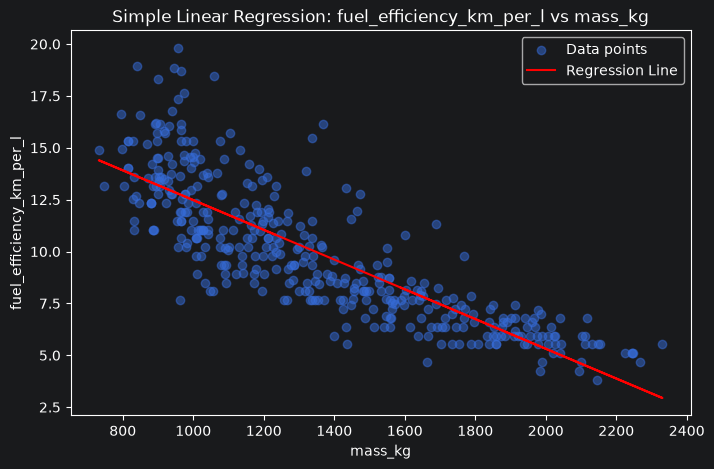

In [61]:
plt.figure(figsize=(8, 5))
plt.scatter(X_simple, y, alpha=0.5, label="Data points")
plt.plot(X_simple, simple_model.predict(X_simple), color="red", label="Regression Line")
plt.xlabel(best_feature)
plt.ylabel(target)
plt.legend()
plt.title(f"Simple Linear Regression: {target} vs {best_feature}")
plt.show()

Step 4: valuate your model honestly

In [62]:
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [63]:
student_id_last4 = 3132
print(f"(Student ID): {student_id_last4}")

(Student ID): 3132


In [64]:
X = df[numeric_cols].drop(columns=[target])
y = df[target]

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=student_id_last4
)

In [66]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0.33,-0.11, 0.14,-0. ,-0.01, 0.05]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['year','cylinders','engine_litres','power_hp','mass_kg','accel_0_100_s']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-640.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [67]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [68]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

train_mae, train_mse, train_rmse, train_r2 = calculate_metrics(y_train, y_train_pred)
test_mae, test_mse, test_rmse, test_r2 = calculate_metrics(y_test, y_test_pred)

In [69]:
print("\n--- Training Set Metrics ---")
print(f"MAE:  {train_mae:.4f}")
print(f"MSE:  {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"R²:   {train_r2:.4f}")

print("\n--- Test Set Metrics ---")
print(f"MAE:  {test_mae:.4f}")
print(f"MSE:  {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²:   {test_r2:.4f}")


--- Training Set Metrics ---
MAE:  1.1371
MSE:  2.1997
RMSE: 1.4831
R²:   0.8039

--- Test Set Metrics ---
MAE:  1.0687
MSE:  1.7218
RMSE: 1.3122
R²:   0.8285


In [70]:
kf = KFold(n_splits=5, shuffle=True, random_state=student_id_last4)
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

In [71]:
print("\n--- 5-Fold Cross-Validation (Test-Fold R²) ---")
print(f"Mean R²: {cv_scores.mean():.4f}")
print(f"Std R²:  {cv_scores.std():.4f}")


--- 5-Fold Cross-Validation (Test-Fold R²) ---
Mean R²: 0.7990
Std R²:  0.0272


## STEP 5: Multiple Linear Regression

In [72]:
all_features = [c for c in numeric_cols if c != target]
remaining_features = [f for f in all_features if f != best_feature]

In [73]:
feature_groups = {
    f"Only Best ({best_feature})": [best_feature],
    f"+ One More ({best_feature} + {remaining_features[0]})": [
        best_feature,
        remaining_features[0],
    ],
    "All Numeric Features": all_features,
}

In [74]:
results = []
kf = KFold(n_splits=5, shuffle=True, random_state=3132)

In [75]:
for group_name, features in feature_groups.items():
    X_subset = df[features]
    cv_scores = cross_val_score(
        LinearRegression(), X_subset, y, cv=kf, scoring="r2"
    )
    results.append(
        {
            "Features Used": group_name,
            "Mean Test R² (5-fold)": f"{cv_scores.mean():.4f}",
            "Std Test R²": f"{cv_scores.std():.4f}",
        }
    )


In [76]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Features Used Mean Test R² (5-fold) Std Test R²
        Only Best (mass_kg)                0.6934      0.0576
+ One More (mass_kg + year)                0.8036      0.0298
       All Numeric Features                0.7990      0.0272


STEP 6: Polynomial Regression

In [77]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [78]:
X_single = df[[best_feature]]
y = df[target]

In [79]:
degrees = range(1, 6)
train_r2_scores = []
cv_test_r2_scores = []

In [80]:
kf = KFold(n_splits=5, shuffle=True, random_state=3132)

In [81]:
for degree in degrees:
    pipe = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression(),
    )

    pipe.fit(X_single, y)
    y_pred_train = pipe.predict(X_single)
    train_r2 = r2_score(y, y_pred_train)
    train_r2_scores.append(train_r2)

    cv_scores = cross_val_score(pipe, X_single, y, cv=kf, scoring="r2")
    cv_test_r2_scores.append(cv_scores.mean())

    print(
        f"Degree {degree}: Train R² = {train_r2:.4f}, Test R² (5-fold CV) = {cv_scores.mean():.4f}"
    )


Degree 1: Train R² = 0.6925, Test R² (5-fold CV) = 0.6934
Degree 2: Train R² = 0.7151, Test R² (5-fold CV) = 0.7148
Degree 3: Train R² = 0.7151, Test R² (5-fold CV) = 0.7143
Degree 4: Train R² = 0.7154, Test R² (5-fold CV) = 0.7139
Degree 5: Train R² = 0.7160, Test R² (5-fold CV) = 0.7139


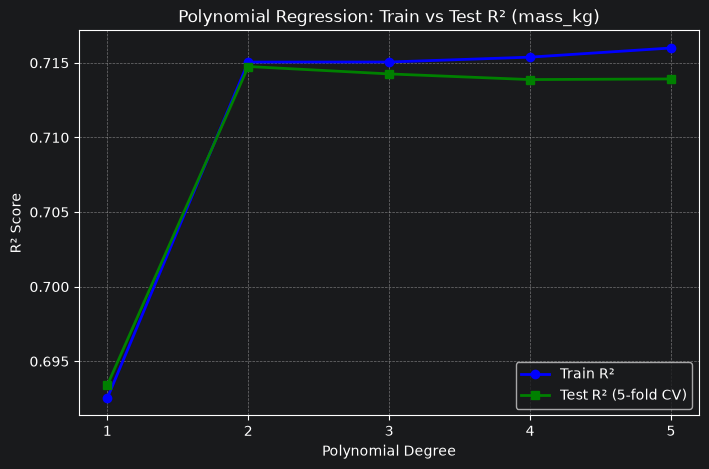

In [82]:
plt.figure(figsize=(8, 5))
plt.plot(
    degrees,
    train_r2_scores,
    marker="o",
    label="Train R²",
    color="blue",
    linewidth=2,
)
plt.plot(
    degrees,
    cv_test_r2_scores,
    marker="s",
    label="Test R² (5-fold CV)",
    color="green",
    linewidth=2,
)
plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")
plt.title(f"Polynomial Regression: Train vs Test R² ({best_feature})")
plt.xticks(degrees)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()